In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load data
data = pd.read_csv('/content/new_User_acquisition_First_user_primary_channel_group_(Default_Channel_Group) (1).csv')

# Display data structure
data_info = pd.DataFrame({
    'Total Rows': [data.shape[0]],
    'Total Columns': [data.shape[1]]
})
display(data_info)

# Display first few rows
display(data.head())

# Display column names
column_df = pd.DataFrame({'Column Names': data.columns})
display(column_df)

# Display missing values
missing_values = pd.DataFrame(data.isnull().sum(), columns=['Missing Values'])
display(missing_values)

,Total Rows,Total Columns
0,100000,11


,First user primary channel group (Default Channel Group),Page path and screen class,Active users,Total users,New users,Returning users,Average engagement time per active user,Engaged sessions per active user,Event count,Key events,User key event rate
0,Direct,/yeokens/get-banking,172806,174373,10389,82465,35.005903,2.733661,883673,0,0
1,Direct,/yeokens/sign-in,149154,150950,32566,56817,26.681785,1.911239,919131,0,0
2,Direct,/yeokens/hub,133043,133453,4592,61464,87.008441,2.669994,740214,0,0
3,Direct,/yeokens/dairy-go-round,104072,108609,16601,54355,114.399176,5.264711,1842931,0,0
4,Direct,/yeokens/welcome,96432,96663,80717,8295,12.037882,1.083593,390451,0,0


,Column Names
0,First user primary channel group (Default Chan...
1,Page path and screen class
2,Active users
3,Total users
4,New users
5,Returning users
6,Average engagement time per active user
7,Engaged sessions per active user
8,Event count
9,Key events


,Missing Values
First user primary channel group (Default Channel Group),0
Page path and screen class,0
Active users,0
Total users,0
New users,0
Returning users,0
Average engagement time per active user,0
Engaged sessions per active user,0
Event count,0
Key events,0


In [ ]:
# Define the Top 3 Channels
top_3_channels = ['Direct', 'Organic Search', 'Email']

# Filter dataset
filtered_top3 = data[data['First user primary channel group (Default Channel Group)'].isin(top_3_channels)]


In [ ]:
# Group by Channel + Page path
top_pages_top3 = filtered_top3.groupby(['First user primary channel group (Default Channel Group)', 'Page path and screen class']).agg({
    'Active users': 'sum',
    'Average engagement time per active user': 'mean'
}).reset_index()

# Sort by Active Users within each channel
top_pages_top3 = top_pages_top3.sort_values(['First user primary channel group (Default Channel Group)', 'Active users'], ascending=[True, False])

# Get Top 5 Pages per Channel
top_5_pages_per_channel = top_pages_top3.groupby('First user primary channel group (Default Channel Group)').head(5).reset_index(drop=True)

# Display result
print("Top 5 Pages for Direct, Organic Search, and Email channels:")
display(top_5_pages_per_channel)


Top 5 Pages for Direct, Organic Search, and Email channels:


,First user primary channel group (Default Channel Group),Page path and screen class,Active users,Average engagement time per active user
0,Direct,/yeokens/get-banking,172806,35.005903
1,Direct,/yeokens/sign-in,149154,26.681785
2,Direct,/yeokens/hub,133043,87.008441
3,Direct,/yeokens/dairy-go-round,104072,114.399176
4,Direct,/yeokens/welcome,96432,12.037882
5,Email,/yeokens/sign-in,87959,21.876658
6,Email,/yeokens/dairy-go-round,83588,72.562485
7,Email,/yeokens/raffle,55097,52.905548
8,Email,/yeokens/hub,46468,77.682018
9,Email,/yeokens/spend,27087,64.352900


In [ ]:
# Find top 5 channels by active users (or sessions/new users depending on your focus)
top_channels = data.groupby('First user primary channel group (Default Channel Group)')['Active users'].sum().sort_values(ascending=False).head(5)

print(top_channels)


First user primary channel group (Default Channel Group)
Direct            1430234
Organic Search     759685
Email              515743
Referral            48155
Organic Social      25684
Name: Active users, dtype: int64


**Top 5 Channel Groups based on Active Users**

In [ ]:
top_channels_list = ['Direct', 'Organic Search', 'Email', 'Referral', 'Organic Social']


In [ ]:
filtered_data = data[data['First user primary channel group (Default Channel Group)'].isin(top_channels_list)]

# Existing aggregation
channel_analysis = filtered_data.groupby('First user primary channel group (Default Channel Group)').agg({
    'New users': 'sum',
    'Returning users': 'sum',
    'Active users': 'sum'
}).reset_index()

# Enforce the correct order from your Top 5
channel_analysis = channel_analysis.set_index('First user primary channel group (Default Channel Group)')
channel_analysis = channel_analysis.loc[top_channels_list].reset_index()

# Optional - Calculate % if needed
channel_analysis['% New Users'] = (channel_analysis['New users'] / channel_analysis['Active users']) * 100
channel_analysis['% Returning Users'] = (channel_analysis['Returning users'] / channel_analysis['Active users']) * 100

display(channel_analysis)


,First user primary channel group (Default Channel Group),New users,Returning users,Active users,% New Users,% Returning Users
0,Direct,213691,696000,1430234,14.940982,48.663366
1,Organic Search,114367,317871,759685,15.054529,41.842474
2,Email,109291,221790,515743,21.190981,43.003977
3,Referral,11934,15775,48155,24.782473,32.758800
4,Organic Social,19472,3505,25684,75.813736,13.646628


**New vs Returning Users Analysis**

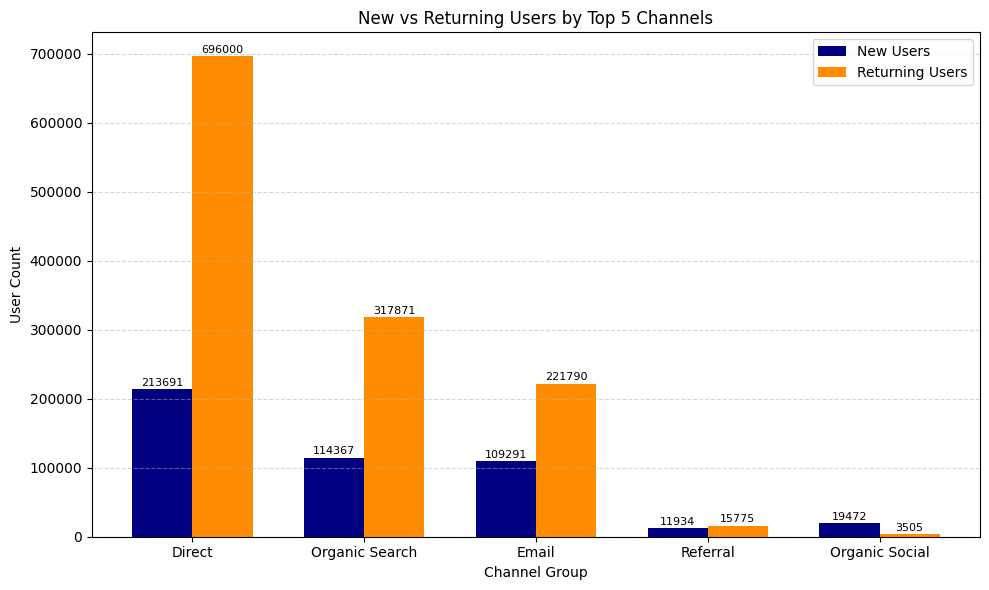

In [ ]:
# Step 4: Visualization - Grouped bar chart (side-by-side bars)
plt.figure(figsize=(10,6))
x = np.arange(len(channel_analysis['First user primary channel group (Default Channel Group)']))
bar_width = 0.35

plt.bar(x - bar_width/2, channel_analysis['New users'], width=bar_width, label='New Users', color='navy')
plt.bar(x + bar_width/2, channel_analysis['Returning users'], width=bar_width, label='Returning Users', color='darkorange')

# Add value labels on bars
for i in range(len(x)):
    plt.text(x[i] - bar_width/2, channel_analysis['New users'][i] + 5000, int(channel_analysis['New users'][i]), ha='center', fontsize=8)
    plt.text(x[i] + bar_width/2, channel_analysis['Returning users'][i] + 5000, int(channel_analysis['Returning users'][i]), ha='center', fontsize=8)

plt.xlabel('Channel Group')
plt.ylabel('User Count')
plt.title('New vs Returning Users by Top 5 Channels')
plt.xticks(x, channel_analysis['First user primary channel group (Default Channel Group)'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


***Channel-wise Breakdown of Top 5 Performing Pages ***

In [ ]:
# Step 1: Filter for only Top 5 Channels (already done earlier)
# Assuming 'filtered_data' already contains Top 5 channel data

# Step 2: Group by Channel and Page, and aggregate metrics
grouped_pages = filtered_data.groupby(['First user primary channel group (Default Channel Group)', 'Page path and screen class']).agg({
    'New users': 'sum',
    'Returning users': 'sum',
    'Active users': 'sum',
    'Average engagement time per active user': 'mean',
    'Engaged sessions per active user': 'mean'
}).reset_index()

# Step 3: Get Top 5 pages for each channel based on 'Active Users' or 'New users'
n = 5
top_pages_by_channel = grouped_pages.groupby('First user primary channel group (Default Channel Group)', group_keys=False).apply(
    lambda x: x.sort_values(by='Active users', ascending=False).head(n)
).reset_index(drop=True)

# Step 4: Display or export the final dataset
display(top_pages_by_channel)


<ipython-input-14-ce8c7e38d5ce>:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_pages_by_channel = grouped_pages.groupby('First user primary channel group (Default Channel Group)', group_keys=False).apply(


,First user primary channel group (Default Channel Group),Page path and screen class,New users,Returning users,Active users,Average engagement time per active user,Engaged sessions per active user
0,Direct,/yeokens/get-banking,10389,82465,172806,35.005903,2.733661
1,Direct,/yeokens/sign-in,32566,56817,149154,26.681785,1.911239
2,Direct,/yeokens/hub,4592,61464,133043,87.008441,2.669994
3,Direct,/yeokens/dairy-go-round,16601,54355,104072,114.399176,5.264711
4,Direct,/yeokens/welcome,80717,8295,96432,12.037882,1.083593
5,Email,/yeokens/sign-in,631,24712,87959,21.876658,1.663184
6,Email,/yeokens/dairy-go-round,41522,31096,83588,72.562485,3.062712
7,Email,/yeokens/raffle,24671,19911,55097,52.905548,1.545057
8,Email,/yeokens/hub,204,20174,46468,77.682018,2.108268
9,Email,/yeokens/spend,423,12161,27087,64.352900,1.614944


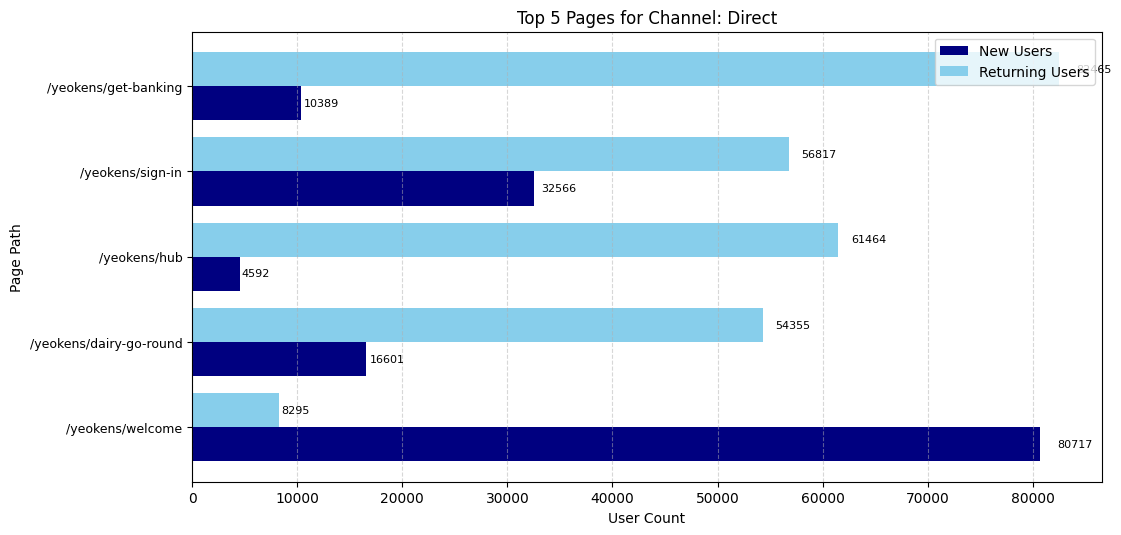

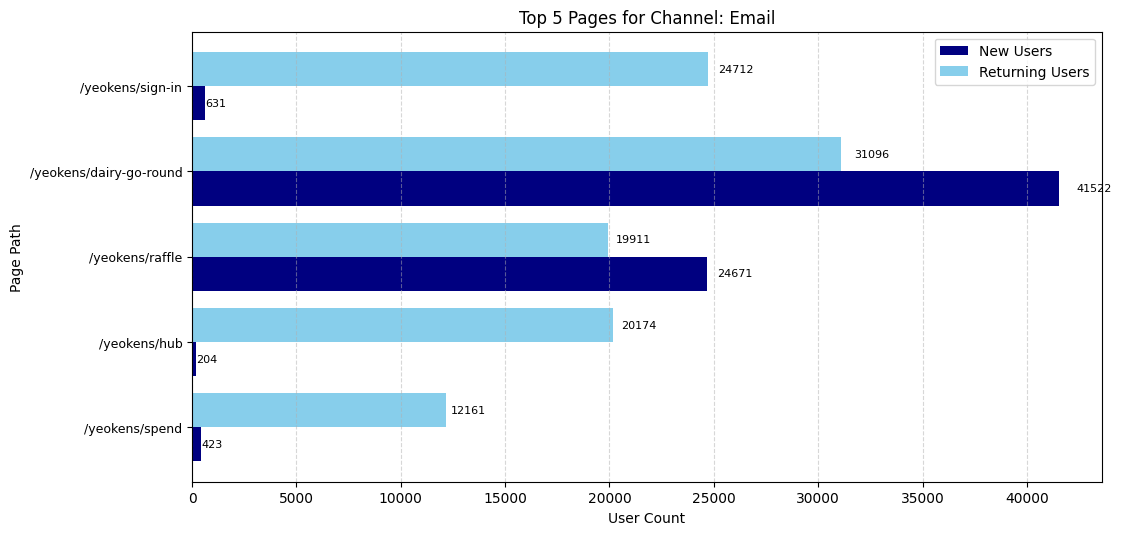

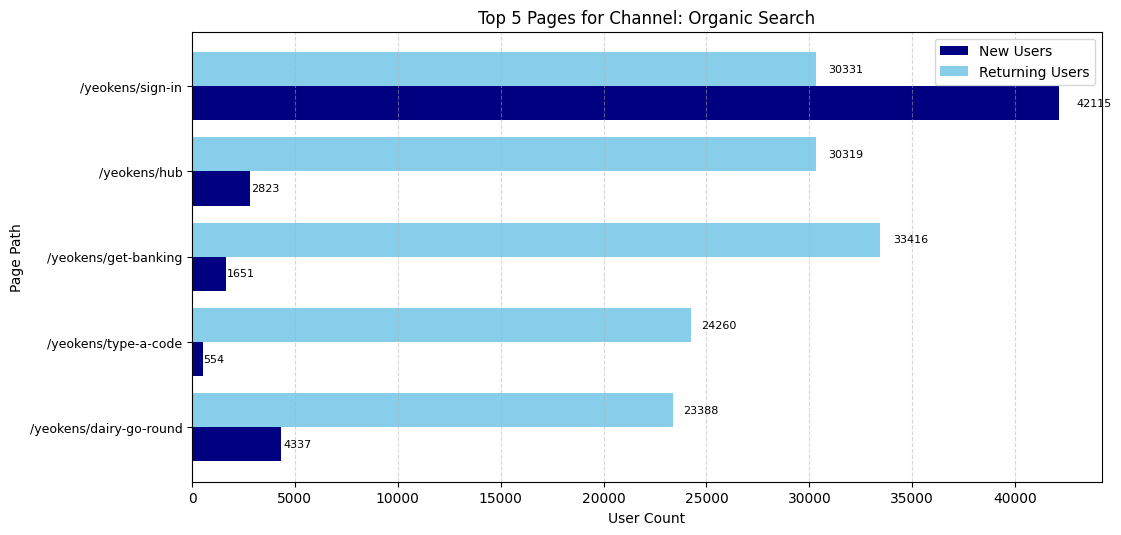

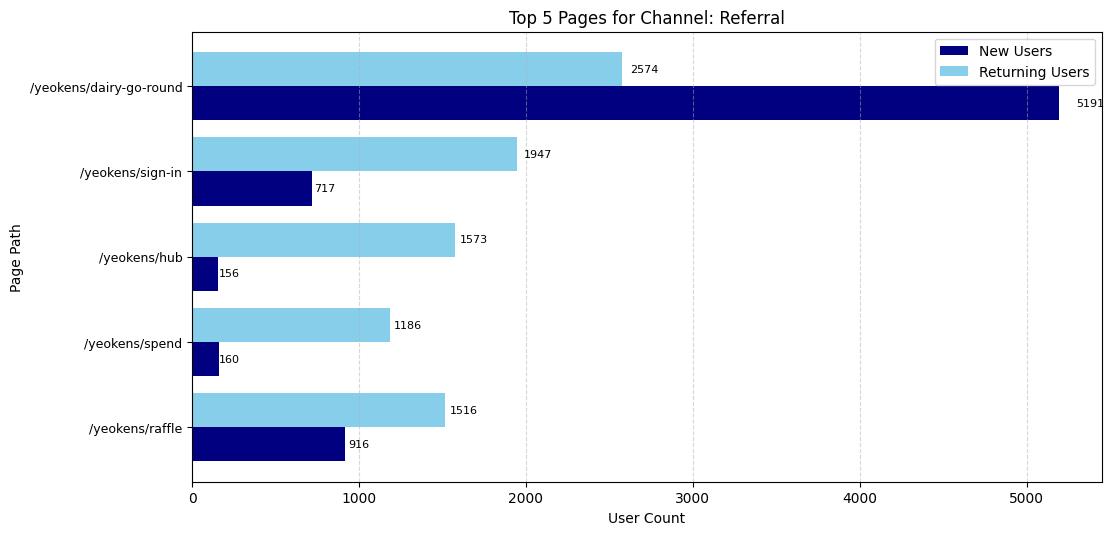

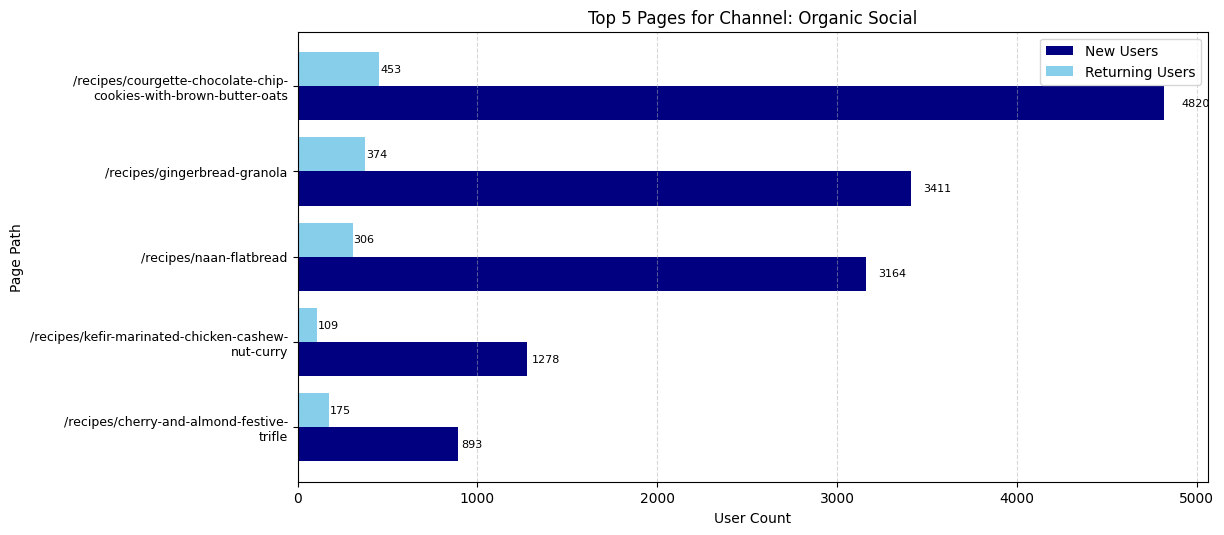

In [ ]:
import textwrap

# Loop through each of the Top 5 Channels
for channel in filtered_data['First user primary channel group (Default Channel Group)'].unique():
    subset = top_pages_by_channel[top_pages_by_channel['First user primary channel group (Default Channel Group)'] == channel]

    # Sort by Active Users DESC + reverse for proper plotting order (top-down visually)
    subset = subset.sort_values(by='Active users', ascending=False)
    subset = subset.iloc[::-1]

    fig_height = max(5, len(subset) * 1.2)
    plt.figure(figsize=(14, fig_height))

    y = np.arange(len(subset))
    bar_width = 0.4

    wrapped_labels = [textwrap.fill(label, width=40) for label in subset['Page path and screen class']]

    # Plotting horizontal bars with updated colors
    bars1 = plt.barh(y - bar_width/2, subset['New users'], height=bar_width, label='New Users', color='navy')
    bars2 = plt.barh(y + bar_width/2, subset['Returning users'], height=bar_width, label='Returning Users', color='skyblue')

    for bar in bars1:
         offset = bar.get_width() * 0.02
         plt.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2, int(bar.get_width()),
                  va='center', ha='left', fontsize=8, color='black')
    for bar in bars2:
         offset = bar.get_width() * 0.02
         plt.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2, int(bar.get_width()),
                  va='center', ha='left', fontsize=8, color='black')

    plt.yticks(y, wrapped_labels, fontsize=9)
    plt.xlabel('User Count')
    plt.ylabel('Page Path')
    plt.title(f"Top 5 Pages for Channel: {channel}", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.subplots_adjust(left=0.3, right=0.95, top=0.9, bottom=0.15)
    plt.show()
